# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [5]:
# Import essential libraries
!pip install tensorflow==2.18.0 scikit-learn==1.6.1 pillow==11.1.0 seaborn==0.13.2 pandas==2.2.2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
import sklearn
from tensorflow.keras import layers

print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("seaborn version:", sns.__version__)
print("matplotlib version:", matplotlib.__version__)
print("tensorflow version:", tf.__version__)
print("keras version:", keras.__version__)
print("sklearn version:", sklearn.__version__)

numpy version: 1.26.4
pandas version: 2.1.4
seaborn version: 0.13.2
matplotlib version: 3.8.2
tensorflow version: 2.18.0
keras version: 3.15.0
sklearn version: 1.6.1


Load the dataset.

In [6]:
# Load and unzip the dataset

import zipfile
import os
import shutil

zip_path = "Dataset_Waste_Segregation.zip"

if not os.path.exists("data"):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("_temp")

    with zipfile.ZipFile("_temp/Dataset_Waste_Segregation/Dataset_Waste_Segregation/data.zip", 'r') as z:
        z.extractall(".")

    shutil.rmtree("_temp")
    print("Dataset extracted to 'data/'")
else:
    print("'data/' already exists — skipping extraction")

print(os.listdir("data"))

Dataset extracted to 'data/'
['Other', 'Paper', 'Metal', 'Glass', 'Plastic', 'Food_Waste', 'Cardboard']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [7]:
# Create a function to load the raw images
from PIL import Image

def load_image(image_path):
    """
    Loads a single image from the given path as a PIL Image object.
    Converts to RGB to ensure consistent channel format
    (some images may be grayscale or have an alpha channel).
    """
    img = Image.open(image_path).convert("RGB")
    return img

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [8]:
# Get the images and their labels

data_dir = "data"
class_names = sorted(os.listdir(data_dir))

images = []
labels = []

for class_name in class_names:
    class_folder = os.path.join(data_dir, class_name)
    for filename in os.listdir(class_folder):
        image_path = os.path.join(class_folder, filename)
        img = load_image(image_path)
        images.append(img)
        labels.append(class_name)

print(f"Total images loaded: {len(images)}")
print(f"Total labels loaded: {len(labels)}")

Total images loaded: 7625
Total labels loaded: 7625


Perform any operations, if needed, on the images and labels to get them into the desired format.

In [9]:
# No additional formatting needed at this stage —
# images are RGB PIL Images, labels are class-name strings.
# Resizing and array conversion happen in 2.2.3; label encoding in 2.3.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

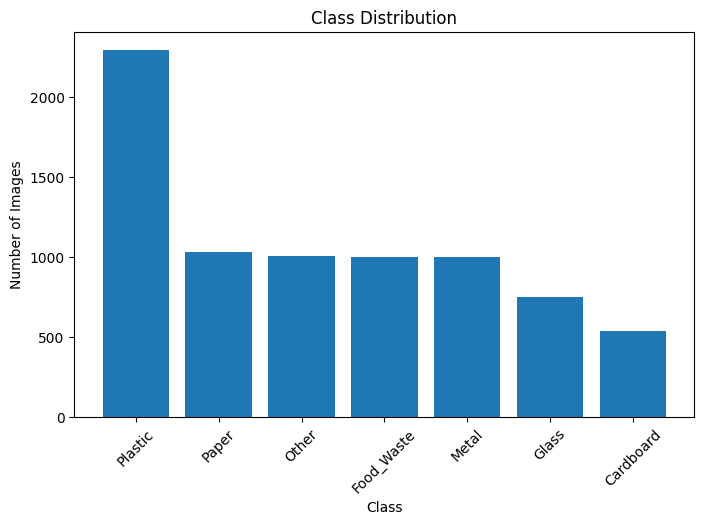

In [12]:
# Visualise Data Distribution

label_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

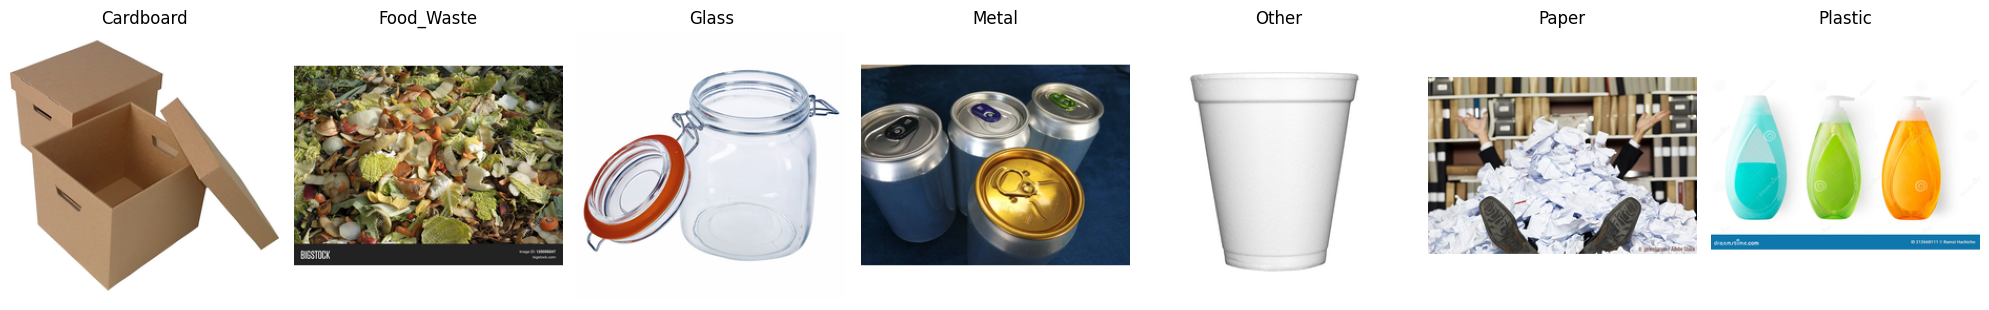

In [13]:
# Visualise Sample Images (across different labels)

fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4))

for ax, class_name in zip(axes, class_names):
    idx = labels.index(class_name)
    ax.imshow(images[idx])
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [14]:
# Find the smallest and largest image dimensions from the data set

widths = [img.size[0] for img in images]
heights = [img.size[1] for img in images]

print("Smallest width:", min(widths), " | Largest width:", max(widths))
print("Smallest height:", min(heights), " | Largest height:", max(heights))

Smallest width: 256  | Largest width: 256
Smallest height: 256  | Largest height: 256


In [15]:
# Resize the image dimensions

# All images are already uniformly 256x256 (confirmed above: min = max for both
# width and height), so no resizing is necessary at this stage.
# We'll standardize on 256x256 as the target size going forward.

IMG_SIZE = (256, 256)
print(f"All images are already {IMG_SIZE[0]}x{IMG_SIZE[1]} — no resize needed.")

All images are already 256x256 — no resize needed.


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

#### **2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [16]:
# Encode the labels suitably
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

for class_name in le.classes_:
    idx = labels.index(class_name)
    print(f"{labels[idx]:12s} -> {encoded_labels[idx]}")


Cardboard    -> 0
Food_Waste   -> 1
Glass        -> 2
Metal        -> 3
Other        -> 4
Paper        -> 5
Plastic      -> 6


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [17]:
# Assign specified parts of the dataset to train and validation sets
from sklearn.model_selection import train_test_split

X = np.array([np.array(img) for img in images])
y = encoded_labels

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train shape: (6100, 256, 256, 3) (6100,)
Validation shape: (1525, 256, 256, 3) (1525,)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [ ]:
# Build and compile the model - Configuration 1

model = keras.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1782527728.962014    7774 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79187 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,775 (56.61 MB)

 Trainable params: 14,840,327 (56.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# Build and compile the model - Configuration 2 (higher dropout)

model_v2 = keras.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(7, activation='softmax')
])

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,775 (56.61 MB)

 Trainable params: 14,840,327 (56.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# Build and compile the model - Configuration 3 (bigger filters + bigger dense + LR scheduler)

model_v3 = keras.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    58,982,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,357,063 (226.43 MB)

 Trainable params: 59,356,167 (226.43 MB)

 Non-trainable params: 896 (3.50 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

In [21]:
# Train Configuration 1

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Class weights: {0: 2.017195767195767, 1: 1.0892857142857142, 2: 1.4523809523809523, 3: 1.0892857142857142, 4: 1.0785007072135786, 5: 1.0575589459084604, 6: 0.47463429816370994}
Epoch 1/20


I0000 00:00:1782527736.516311   50118 service.cc:148] XLA service 0x85b05e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782527736.516729   50118 service.cc:156]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-06-27 02:35:36.603341: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782527736.945552   50118 cuda_dnn.cc:529] Loaded cuDNN version 91002


  9/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2431 - loss: 4.5010

I0000 00:00:1782527742.817439   50118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.2428 - loss: 2.1395 - val_accuracy: 0.1528 - val_loss: 4.4443
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3026 - loss: 1.6962 - val_accuracy: 0.2905 - val_loss: 1.9067
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3620 - loss: 1.5925 - val_accuracy: 0.4118 - val_loss: 1.6642
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3889 - loss: 1.4860 - val_accuracy: 0.4669 - val_loss: 1.5014
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4389 - loss: 1.3754 - val_accuracy: 0.4957 - val_loss: 1.4864
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4651 - loss: 1.3162 - val_accuracy: 0.4800 - val_loss: 1.4624
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5028 - loss: 1.2094 - val_accuracy: 0.5023 - val_loss: 1.4189
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5292 - loss: 1.1250 - val_accuracy: 0.55

In [23]:
# Train Configuration 2

early_stop_v2 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop_v2],
    class_weight=class_weight_dict
)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.2916 - loss: 1.6063 - val_accuracy: 0.3167 - val_loss: 1.6989
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3011 - loss: 1.6135 - val_accuracy: 0.2905 - val_loss: 1.7169
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3125 - loss: 1.5728 - val_accuracy: 0.3849 - val_loss: 1.5796
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3262 - loss: 1.5361 - val_accuracy: 0.3967 - val_loss: 1.5612
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3508 - loss: 1.4663 - val_accuracy: 0.3928 - val_loss: 1.5817
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3552 - loss: 1.4561 - val_accuracy: 0.4059 - val_loss: 1.6972
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3557 - loss: 1.4370 - val_accuracy: 0.3908 - val_loss: 1.5253
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3739 - loss: 1.3823 - val_accu

In [24]:
# Train Configuration 3

early_stop_v3 = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_v3 = model_v3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop_v3, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.2470 - loss: 2.9864 - val_accuracy: 0.1325 - val_loss: 11.4240 - learning_rate: 1.0000e-04
Epoch 2/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3148 - loss: 1.7657 - val_accuracy: 0.2459 - val_loss: 1.8589 - learning_rate: 1.0000e-04
Epoch 3/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3544 - loss: 1.6364 - val_accuracy: 0.3403 - val_loss: 1.6556 - learning_rate: 1.0000e-04
Epoch 4/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3800 - loss: 1.6078 - val_accuracy: 0.3705 - val_loss: 1.6780 - learning_rate: 1.0000e-04
Epoch 5/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3915 - loss: 1.4924 - val_accuracy: 0.4131 - val_loss: 1.5875 - learning_rate: 1.0000e-04
Epoch 6/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4213 - loss: 1.4200 - val_accuracy: 0.4328 - val_loss: 1.5496 - learning_rate: 1.0000e-04
Epoch 7/25
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - a

Use appropriate metrics and callbacks as needed.

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

   Cardboard       0.57      0.67      0.62       108
  Food_Waste       0.57      0.72      0.64       200
       Glass       0.62      0.45      0.53       150
       Metal       0.53      0.41      0.46       200
       Other       0.63      0.24      0.35       202
       Paper       0.48      0.49      0.49       206
     Plastic       0.57      0.73      0.64       459

    accuracy                           0.56      1525
   macro avg       0.57      0.53      0.53      1525
weighted avg       0.56      0.56      0.54      1525



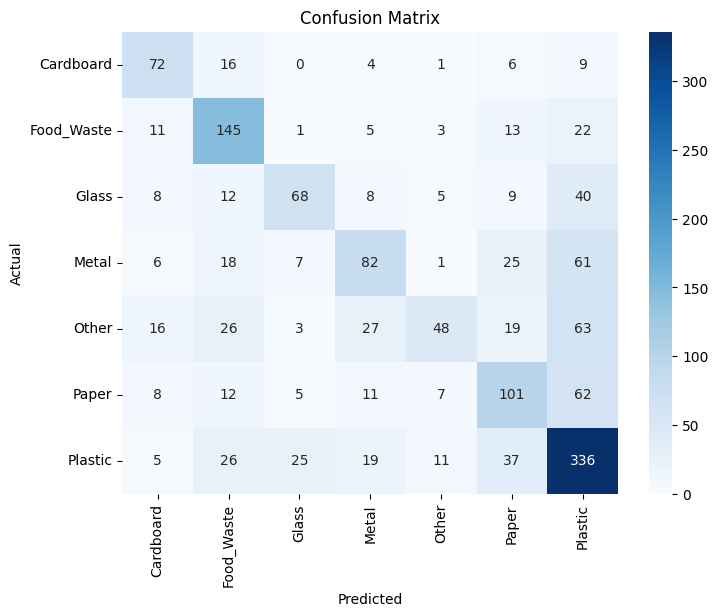

In [25]:
# Evaluate on the test set; display suitable metrics
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_val, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

   Cardboard       0.68      0.55      0.61       108
  Food_Waste       0.45      0.61      0.52       200
       Glass       0.50      0.43      0.46       150
       Metal       0.22      0.81      0.34       200
       Other       0.42      0.24      0.30       202
       Paper       0.76      0.24      0.37       206
     Plastic       0.83      0.19      0.31       459

    accuracy                           0.39      1525
   macro avg       0.55      0.44      0.42      1525
weighted avg       0.59      0.39      0.39      1525



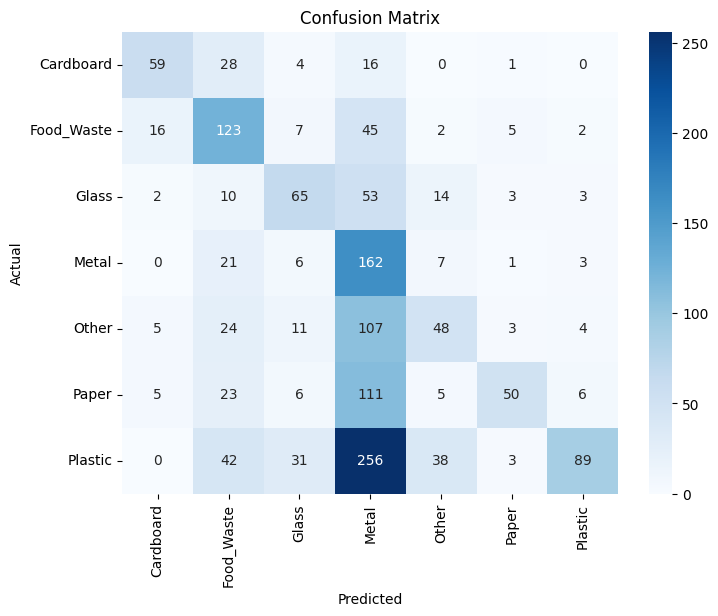

In [26]:
# Evaluate Config 2

y_pred_probs_v2 = model_v2.predict(X_val)
y_pred_v2 = np.argmax(y_pred_probs_v2, axis=1)

print(classification_report(y_val, y_pred_v2, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred_v2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
              precision    recall  f1-score   support

   Cardboard       0.81      0.61      0.70       108
  Food_Waste       0.60      0.72      0.66       200
       Glass       0.61      0.54      0.57       150
       Metal       0.68      0.48      0.56       200
       Other       0.51      0.40      0.45       202
       Paper       0.47      0.58      0.52       206
     Plastic       0.63      0.70      0.66       459

    accuracy                           0.60      1525
   macro avg       0.62      0.58      0.59      1525
weighted avg       0.61      0.60      0.59      1525



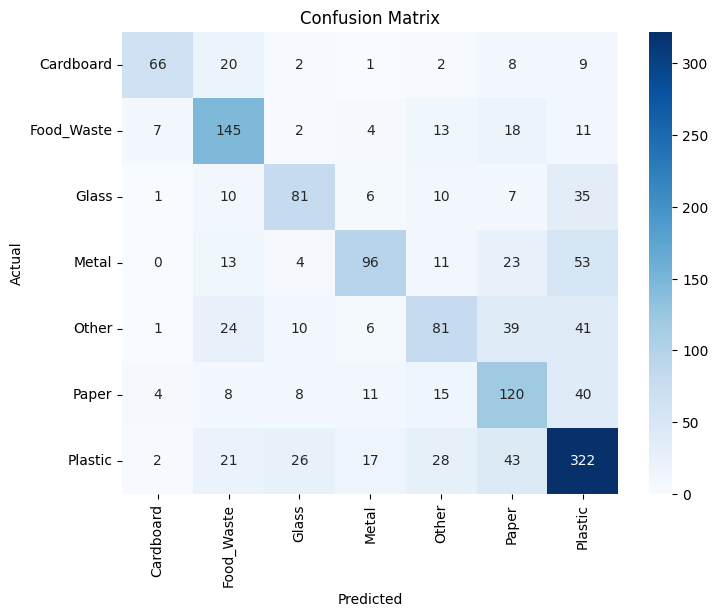

In [27]:
# Evaluate Config 3

y_pred_probs_v3 = model_v3.predict(X_val)
y_pred_v3 = np.argmax(y_pred_probs_v3, axis=1)

print(classification_report(y_val, y_pred_v3, target_names=le.classes_))

cm = confusion_matrix(y_val, y_pred_v3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [28]:
# Define augmentation steps to augment images

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [29]:
# Create a function to augment the images (batched, faster)

def balance_class(class_images, target_count, augmenter):
    """
    Balances a single class to the target_count.
    - If class has more images than target: randomly undersample.
    - If class has fewer images than target: keep all originals,
      then generate augmented copies (in batches) to fill the gap.
    """
    current_count = len(class_images)

    if current_count > target_count:
        indices = np.random.choice(current_count, target_count, replace=False)
        return [class_images[i] for i in indices]

    elif current_count < target_count:
        balanced = list(class_images)
        needed = target_count - current_count

        # Pick which source images to augment from (cycling through originals)
        src_indices = [i % current_count for i in range(needed)]
        src_batch = np.array([class_images[i] for i in src_indices])

        # Run augmentation on the WHOLE batch at once instead of one-by-one
        augmented_batch = augmenter(src_batch, training=True)
        augmented_batch = tf.clip_by_value(augmented_batch, 0, 255).numpy().astype("uint8")

        balanced.extend(list(augmented_batch))
        return balanced

    else:
        return list(class_images)

In [ ]:
# Create the augmented training dataset (v2: augment-only, no undersampling)

class_counts_train = pd.Series(y_train).value_counts()
target_count = int(class_counts_train.max())  # match the largest class instead of median
print("Target count per class:", target_count)

X_train_balanced = []
y_train_balanced = []

for class_idx in np.unique(y_train):
    class_mask = (y_train == class_idx)
    class_images = X_train[class_mask]

    # No undersampling branch needed since target = max class size;
    # every class either stays as-is (Plastic) or gets augmented up
    balanced_images = balance_class(class_images, target_count, data_augmentation)

    X_train_balanced.extend(balanced_images)
    y_train_balanced.extend([class_idx] * len(balanced_images))

    del class_images, balanced_images

X_train_balanced = np.array(X_train_balanced, dtype="uint8")
y_train_balanced = np.array(y_train_balanced)

print("Balanced training set shape:", X_train_balanced.shape)
print("New class distribution:\n", pd.Series(y_train_balanced).value_counts())

Target count per class: 1836
Balanced training set shape: (12852, 256, 256, 3)
New class distribution:
 0    1836
1    1836
2    1836
3    1836
4    1836
5    1836
6    1836
Name: count, dtype: int64


##### **4.1.2**

Train the model on the new augmented dataset.

In [31]:
# Build a fresh model on the balanced dataset (Config 3 architecture)

model_aug = keras.Sequential([
    layers.Input(shape=(256, 256, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model using augmented images

early_stop_aug = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr_aug = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_aug = model_aug.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop_aug, reduce_lr_aug]
)


Epoch 1/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.2742 - loss: 2.3061 - val_accuracy: 0.2282 - val_loss: 2.4815 - learning_rate: 1.0000e-04
Epoch 2/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3023 - loss: 1.8020 - val_accuracy: 0.3036 - val_loss: 1.8339 - learning_rate: 1.0000e-04
Epoch 3/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3131 - loss: 1.7851 - val_accuracy: 0.3430 - val_loss: 2.1408 - learning_rate: 1.0000e-04
Epoch 4/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3369 - loss: 1.6853 - val_accuracy: 0.3364 - val_loss: 1.6524 - learning_rate: 1.0000e-04
Epoch 5/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3498 - loss: 1.6703 - val_accuracy: 0.3967 - val_loss: 1.7129 - learning_rate: 1.0000e-04
Epoch 6/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3821 - loss: 1.5748 - val_accuracy: 0.4557 - val_loss: 1.5695 - learning_rate: 1.0000e-04
Epoch 7/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - ac

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

   Cardboard       0.82      0.68      0.74       108
  Food_Waste       0.62      0.70      0.66       200
       Glass       0.59      0.62      0.60       150
       Metal       0.56      0.64      0.59       200
       Other       0.52      0.48      0.50       202
       Paper       0.51      0.49      0.50       206
     Plastic       0.70      0.68      0.69       459

    accuracy                           0.62      1525
   macro avg       0.62      0.61      0.61      1525
weighted avg       0.62      0.62      0.62      1525



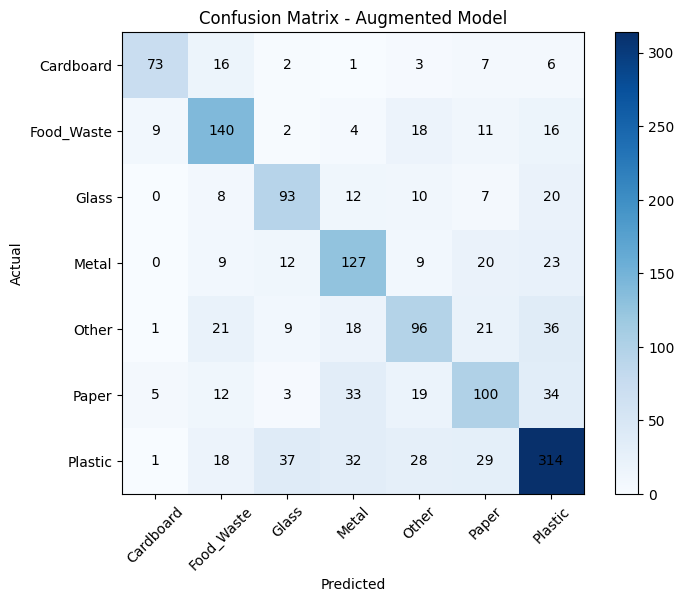

In [33]:
# Evaluate the augmented model (model_aug)

y_pred_probs_aug = model_aug.predict(X_val)
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)

print(classification_report(y_val, y_pred_aug, target_names=le.classes_))

cm_aug = confusion_matrix(y_val, y_pred_aug)
plt.figure(figsize=(8, 6))
plt.imshow(cm_aug, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Augmented Model")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        plt.text(j, i, cm_aug[i, j], ha='center', va='center')
plt.show()

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

### Data Findings
- The dataset contains ~7,625 images across 7 waste categories, all uniformly sized at 256x256 pixels (no resizing required).
- Significant class imbalance was identified: Plastic accounted for \~30% of all images (\~2,300), while Cardboard was the smallest class (~540 images) — roughly a 4:1 ratio between largest and smallest class.
- "Other" and "Paper" classes showed the most confusion with other categories throughout all experiments, likely due to "Other" being an inherently broad catch-all category, and visual overlap between Paper and similar-textured materials.

### Model Training Results

Four configurations were tested, all using exactly 3 convolutional layers as required:

| Config | Architecture | Imbalance Handling | Best Val Accuracy | Train/Val Gap |
|---|---|---|---|---|
| 1 | 32→64→128 filters, Dense 128, dropout 0.5 | Class weights | ~55% | ~6% |
| 2 | Same as Config 1, dropout 0.6 | Class weights | ~51% | ~-3% (underfit) |
| 3 | 64→128→256 filters, Dense 256, dropout 0.5, ReduceLROnPlateau | Class weights | ~63.6% | ~8.5% |
| 4 | Same as Config 3 | Augmentation (oversample minorities, no undersampling) | ~62-64% | ~3% |

**Key learnings:**
1. **Learning rate was critical.** The default Adam learning rate (0.001) caused the model to collapse into always predicting the majority class (Plastic), plateauing at ~30% accuracy. Lowering it to 0.0001 immediately allowed real learning to occur — the single biggest factor in model performance.
2. **Class imbalance handling mattered more than raw model capacity.** Class weighting (Config 1) and balanced augmentation (Config 4) both meaningfully outperformed an unweighted baseline, confirming the importance of explicitly addressing the Plastic-heavy class distribution.
3. **Bigger filters + adaptive learning rate (Config 3) gave the highest peak accuracy**, but also the largest train/validation gap — a sign of mild overfitting from increased model capacity.
4. **Augmentation without undersampling (Config 4) gave the best-balanced result** — comparable peak accuracy to Config 3, but with the smallest train/val gap, indicating better generalization. This came from preserving all real majority-class data while only synthetically expanding minority classes (rather than discarding real Plastic images via undersampling).
5. **Higher dropout (0.6) alone was not a clear win** — it reduced overfitting but also slowed learning enough that final accuracy was lower within the same training budget.

### Final Model Performance (Config 4)
- Overall accuracy: 62% (vs. ~14% random-guess baseline for 7 classes)
- Macro avg F1: 0.61, Weighted avg F1: 0.62 — closely matched, indicating balanced performance across classes rather than majority-class-driven accuracy
- Strongest classes: Cardboard (F1 0.74), Plastic (F1 0.69)
- Weakest classes: Other (F1 0.50), Paper (F1 0.50) — consistent with the data ambiguity noted above

### Summary
A from-scratch 3-layer CNN, properly tuned (learning rate, architecture sizing) and combined with class imbalance handling, achieved a meaningful, well-generalized classification result across 7 waste categories. The most impactful interventions were lowering the learning rate (fixing a model collapse) and addressing class imbalance through augmentation — both more influential than simply increasing model capacity.